In [ ]:
!pip install opencv-python matplotlib

Saving img.jpg to img (6).jpg


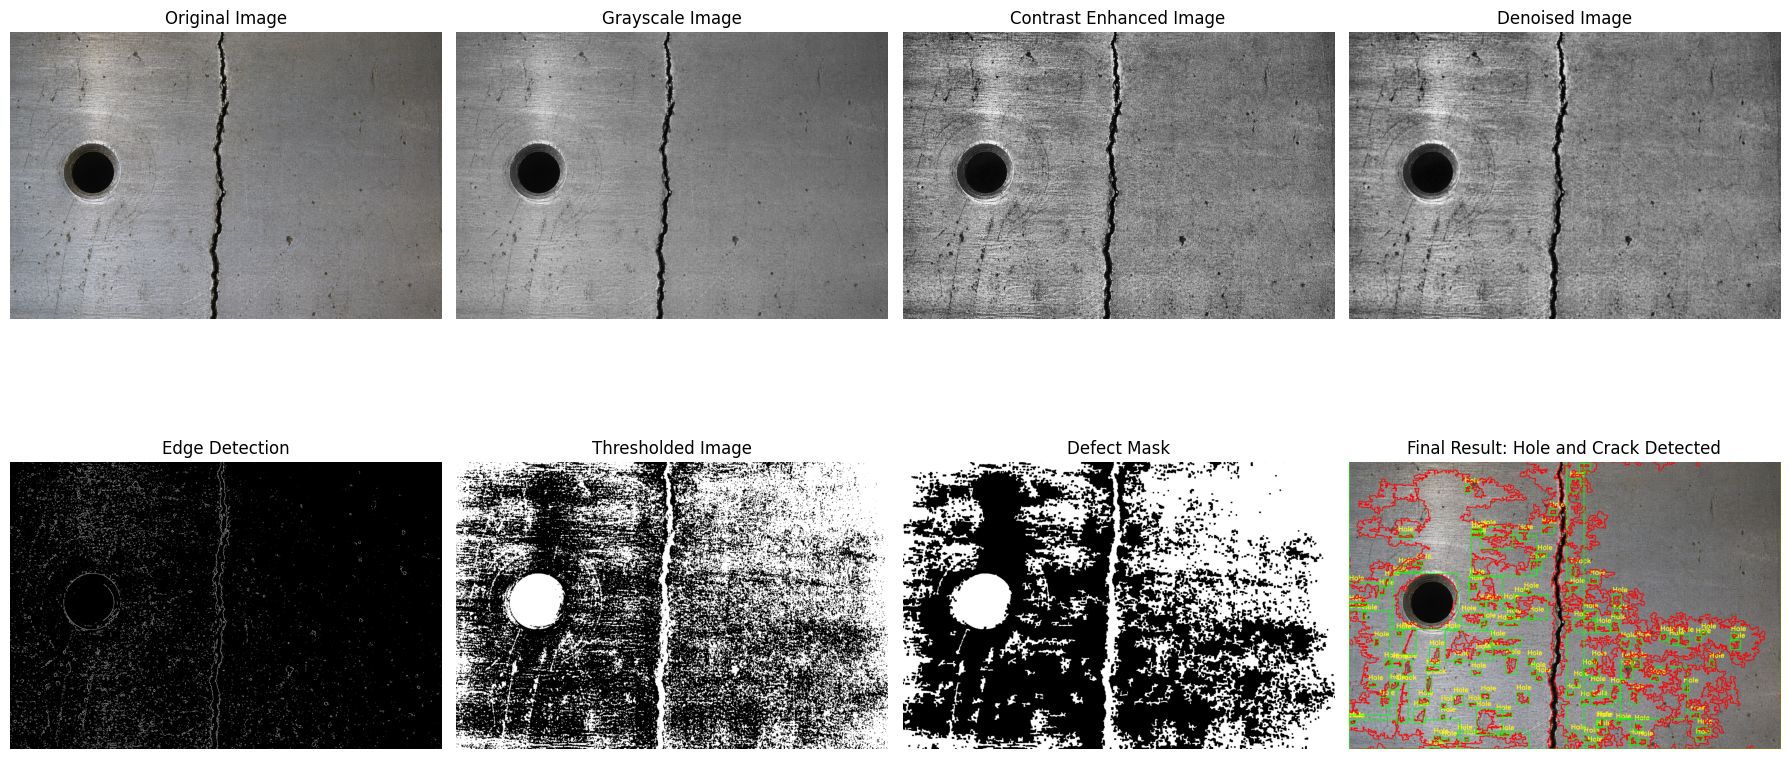

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
contrast = clahe.apply(gray)

denoised = cv2.GaussianBlur(contrast, (5, 5), 0)

median_intensity = np.median(denoised)
lower = max(0, 2 * median_intensity )
upper = min(255, 4 * median_intensity )
edges = cv2.Canny(denoised, lower, upper)

_, thresh = cv2.threshold(
    denoised, 0, 150,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3, 3), np.uint8)
mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

defect_mask = np.zeros_like(mask)

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > 150:
        defect_mask[labels == i] = 255

contours, _ = cv2.findContours(defect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = rgb.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = h / (w + 1e-5)

    if area > 100:
        cv2.drawContours(result, [cnt], -1, (255, 0, 0), 2)

        if aspect_ratio > 2.5:
            label = "Crack"
        else:
            label = "Hole"

        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(result, label, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

images = [
    rgb,
    gray,
    contrast,
    denoised,
    edges,
    thresh,
    defect_mask,
    result
]

titles = [
    "Original Image",
    "Grayscale Image",
    "Contrast Enhanced Image",
    "Denoised Image",
    "Edge Detection",
    "Thresholded Image",
    "Defect Mask",
    "Final Result: Hole and Crack Detected"
]

plt.figure(figsize=(18, 10))

for i in range(len(images)):
    plt.subplot(2, 4, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()